# Visualization

Companion notebook for the RDDAC [documentation](https://rddac.readthedocs.io). It is written to stand on its own: every step is annotated so the notebook reads top to bottom.

## Walkthrough

1. open one experiment with `rddac.open_h5` and pull every modality,
2. render the OP10 and OP20 height scans side by side,
3. look at the luminescence channel in grayscale,
4. lift the scan into a 3D point cloud with `scan_to_pointcloud` + `plot_point_cloud`,
5. plot the press-force signals over time,
6. plot the sheet-thickness and oil-film traverses (and mask the raw sensor spikes).

## Assumptions

- This notebook lives in `notebooks/` of the repository and reads the dataset from `../data/` (on your machine: the directory `rddac download` wrote to).
- The data directory contains `metadata.json`, `process_parameters.csv`, and at least the bundled `sample.zip`.
- All values are **raw sensor units**: the calibrated mm conversion, outlier removal, and simulation alignment belong to the optional preprocessing step.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np

import rddac
print('rddac', rddac.__version__)

from pathlib import Path
DATA_DIR = Path('../data')
# DATA_DIR = Path('./data')   # uncomment instead when running from the repository root
assert (DATA_DIR / 'metadata.json').is_file(), f'{DATA_DIR} does not contain the dataset'
experiment_id = 0

rddac 0.1.0


## 1. Load one experiment

One `open_h5` context is enough to pull every modality (the four scan buffers dominate at ~25 MB each). Reading everything up front keeps the plotting cells below independent of each other.

In [2]:
with rddac.open_h5(experiment_id, data_dir=DATA_DIR) as f:
    z10    = f['pointcloud/op10/z'][:]
    lumi10 = f['pointcloud/op10/luminescence'][:]
    z20    = f['pointcloud/op20/z'][:]
    force  = f['force/data'][:]
    sheet  = f['sheet_thickness/data'][:]
    oil    = f['oil_thickness/data'][:]

for name, arr in [('z10', z10), ('lumi10', lumi10), ('z20', z20),
                  ('force', force), ('sheet', sheet), ('oil', oil)]:
    print(f'  {name:8s} shape={arr.shape}  dtype={arr.dtype}')

  z10      shape=(6400000,)  dtype=float32
  lumi10   shape=(6400000,)  dtype=float32
  z20      shape=(6400000,)  dtype=float32
  force    shape=(1140, 8)  dtype=float32
  sheet    shape=(208, 2)  dtype=float32
  oil      shape=(421, 2)  dtype=float32


## 2. Height scans: OP10 vs OP20

The scans are flat row-major buffers over a 2000 x 3200 grid (`x_shape` / `y_shape` group attributes); `rddac.plot_scan` reshapes and renders them as images. Two conventions to know:

- pixels with value `0` carry **no measurement** and are masked transparent (`mask_zero=True`, the default),
- z values are raw scanner units, so compare shapes and gradients, not absolute numbers.

**OP10** is the part after deep drawing — the full cup with the flange still attached. **OP20** is the same part after the cutting operation — the flange is gone and the trimmed edge is visible. Passing an existing `ax` puts both operations side by side.

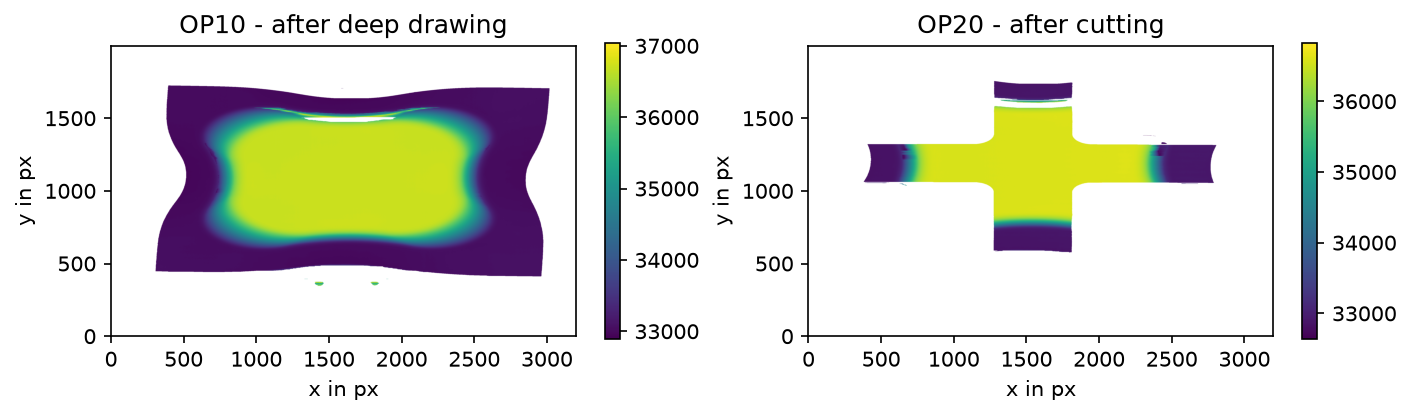

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), dpi=150)
rddac.plot_scan(z10, ax=axes[0], title='OP10 - after deep drawing')
rddac.plot_scan(z20, ax=axes[1], title='OP20 - after cutting')
plt.show()

## 3. The luminescence channel

Each scan also stores a `luminescence` buffer: the intensity of the reflected laser line per pixel. It reads like a grayscale photo of the part and is the natural **validity mask** — pixels where the scanner received no signal are `0` in both channels. Surface features that barely move the height field (scratches, oil residue, texture) often show up here first.

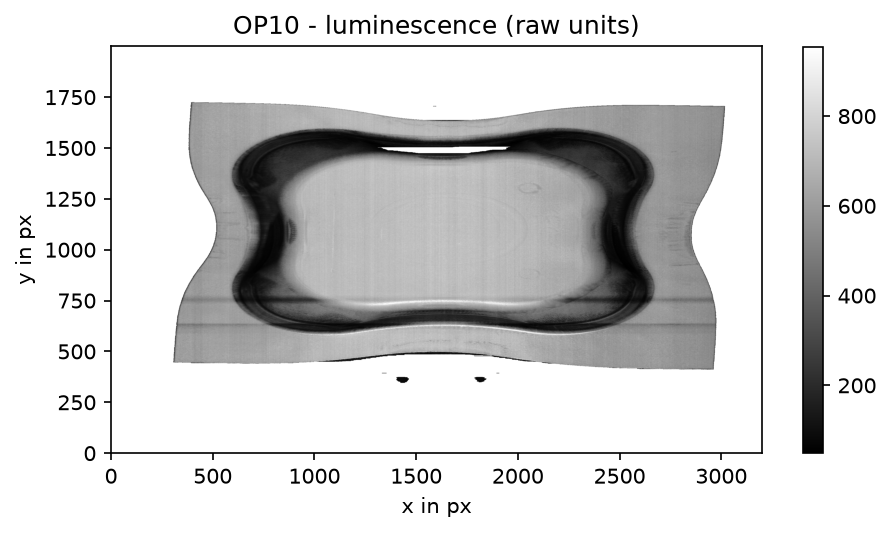

In [4]:
ax, cbar = rddac.plot_scan(lumi10, cmap='gray', figsize=(7, 4.4),
                           title='OP10 - luminescence (raw units)')
plt.show()

## 4. From scan to 3D point cloud

`rddac.scan_to_pointcloud(z, luminescence, stride=...)` converts the flat buffer into an `(N, 3)` array of `[x_px, y_px, z_raw]`:

- invalid pixels (`z == 0`, and `luminescence == 0` when the second buffer is given) are dropped,
- `stride=10` keeps every 10th pixel in both axes, reducing 6.4 M points to a fast ~30 k preview.

`rddac.plot_point_cloud` scatters the result in 3D, coloured by z per default, and randomly subsamples to `max_points` if needed. Coordinates are pixel indices and raw z units — the mm-calibrated, simulation-aligned cloud is what the preprocessing step produces.

point cloud: 31353 points (from 6400000 pixels at stride 10)


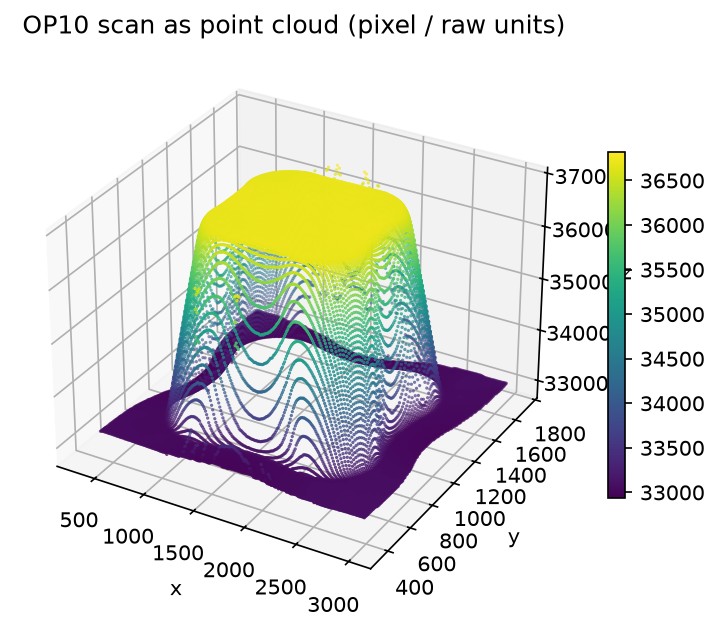

In [5]:
pts = rddac.scan_to_pointcloud(z10, lumi10, stride=10)
print(f'point cloud: {pts.shape[0]} points (from {z10.size} pixels at stride 10)')

ax, cbar = rddac.plot_point_cloud(pts, point_size=0.3, figsize=(6, 5),
                                  title='OP10 scan as point cloud (pixel / raw units)')
plt.show()

## 5. Press-force signals

`force/data` is an `(n, 8)` table; the column names and units are stored on the h5 group (`columns` / `units` attrs) and `rddac.plot_force` defaults to the raw layout: `[time, load_cell_1..4, punch_temp, punch_pos, total_force]`. The default signal selection draws the four load cells plus their sum against time; `punch_temp` (degC) and `punch_pos` (mm) live on other scales and are left out of the kN axis on purpose (pass `signals=(...)` to select different columns).

The curve tells the story of one stroke: contact, force build-up under the blankholder, drawing, and release.

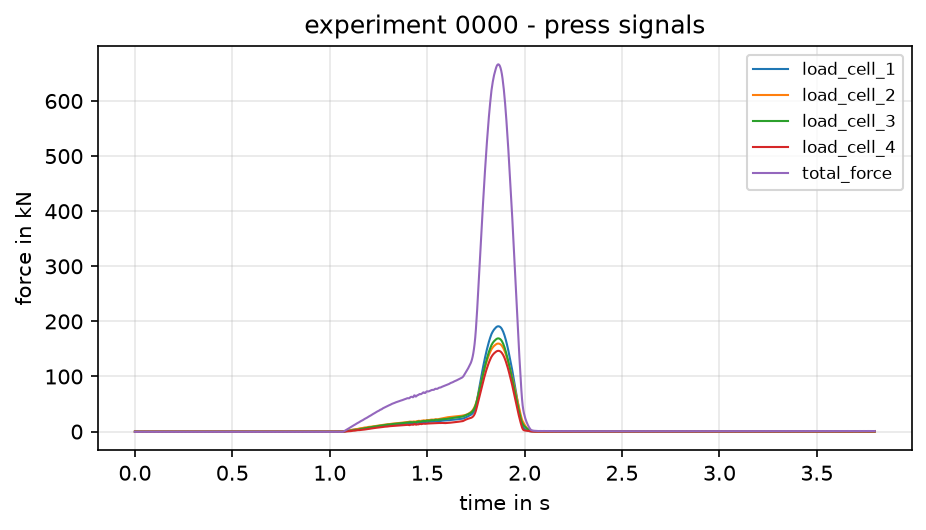

In [6]:
ax = rddac.plot_force(force, figsize=(7, 3.5),
                      title=f'experiment {experiment_id:04d} - press signals')
plt.show()

## 6. Sheet-thickness and oil-film traverses

Both traverses are `(n, 2)` tables of `[sensor_position, value]`, each measured **once per part along a single line on the flat blank** — this is line data, not a full-surface map:

1. the **sheet thickness** is measured first, on the *bare* blank before any oil is applied (incoming material check, values around 1 000 um),
2. then the blank is lubricated and the **oil film** is measured (g/m^2).

Two raw-data quirks to handle when plotting:

- the sheet traverse contains occasional **negative sensor-error spikes** (about -100 000 in this file) — mask `value <= 0` before plotting, otherwise autoscale collapses the curve,
- the sheet sensor positions carry a **+50 mm offset** (50–257 mm) relative to the oil traverse (0–210 mm); subtracting 50 mm puts both lines on the same axis.

masked 2 sensor-error spike(s) out of 208 sheet samples


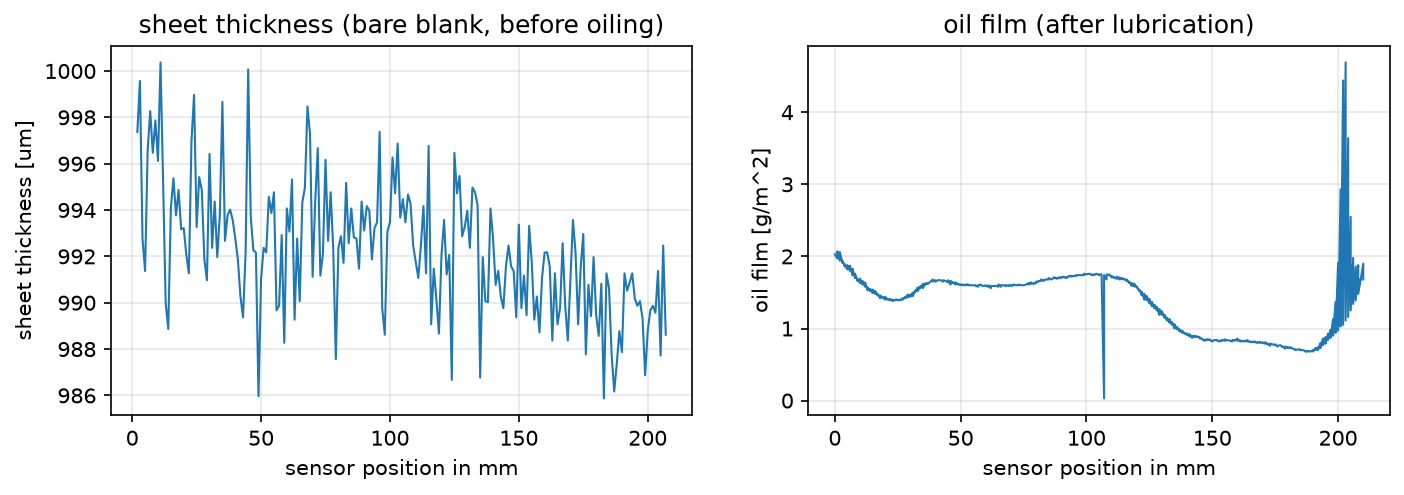

In [7]:
n_spikes = int((sheet[:, 1] <= 0).sum())
sheet_clean = sheet[sheet[:, 1] > 0].copy()
sheet_clean[:, 0] -= 50.0                      # align with the oil traverse's 0-210 mm axis
print(f'masked {n_spikes} sensor-error spike(s) out of {len(sheet)} sheet samples')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), dpi=150)
rddac.plot_traverse(sheet_clean, ax=axes[0], ylabel='sheet thickness [um]',
                    title='sheet thickness (bare blank, before oiling)')
rddac.plot_traverse(oil, ax=axes[1], ylabel='oil film [g/m^2]',
                    title='oil film (after lubrication)')
plt.show()